In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import lpn, lqn
from scipy.optimize import brentq
from scipy.interpolate import interp1d, make_interp_spline, CubicSpline
from scipy.signal import savgol_filter

# %matplotlib widget

mpmath.legenp(n, m, z, type=2)
Calculates the (associated) Legendre function of the first kind of degree n and order m, 
. Taking 
 gives the ordinary Legendre function of the first kind, 
. The parameters may be complex numbers.

## Basis Functions

In [3]:
import mpmath 
# https://mpmath.org/

# https://mpmath.org/doc/current/functions/orthogonal.html#mpmath.legenp

# the legendre polynmial (l,m) is a solution to spherical harmonics.
# for this problem we take m=0, and scan l


def make_M(l):
    """
    Given l, return M_l(x) satisfying:
      M(0)  = 1
      M'(0) = 0
    Returns a callable M(x).
    """
    # Values at x=0
    P0  = float(mpmath.legenp(l, 0, 0).real)
    Q0  = float(mpmath.legenq(l, 0, 0).real)
    dP0 = float(mpmath.diff(lambda z: mpmath.legenp(l, 0, z), 0).real)
    dQ0 = float(mpmath.diff(lambda z: mpmath.legenq(l, 0, z), 0).real)

    # find the linear combination (a,b). This is determined by BCs: M(0) = 1 and M'(0) = 0.
    det = P0 * dQ0 - dP0 * Q0
    a   =  dQ0 / det
    b   = -dP0 / det

    def M(x):
        Px = float(mpmath.legenp(l, 0, x).real)
        Qx = float(mpmath.legenq(l, 0, x).real)
        return a * Px + b * Qx

    return a, b, M


# Usage
l = 2.3
a, b, M = make_M(l)

print(f"a = {a:.6f},  b = {b:.6f}")
print(f"M(0)  = {M(0):.6f}")   # should be 1
print(f"M'(0) = {float(mpmath.diff(M, 0)):.2e}")  # should be ~0

# Evaluate on a grid
import numpy as np
x = np.linspace(0.01, 0.99, 200)
M_vals = np.array([M(xi) for xi in x])

a = -1.882589,  b = 0.610663
M(0)  = 1.000000
M'(0) = 0.00e+00


In [4]:
lax = np.linspace(0.11,12.2,99)
a,b,M = np.transpose([make_M(l) for l in lax])

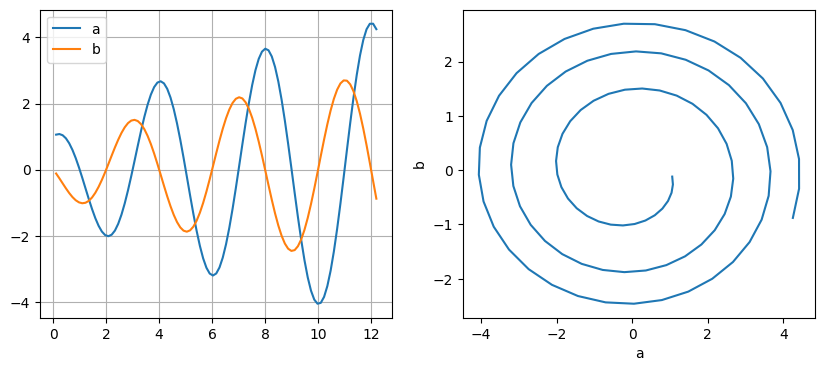

In [5]:
fig,axs = plt.subplots(1,2, figsize=(10,4))

axs[0].plot(lax,a, label='a')
axs[0].plot(lax,b, label='b')
axs[0].legend()
axs[0].grid()

axs[1].plot(a,b)
axs[1].set_xlabel("a")
axs[1].set_ylabel("b")

plt.show()
# Observe that each half-integer of l is pi/2 rotation in (a,b)


In [6]:
lax = np.linspace(0.11,25.3,159)
a,b,M = np.transpose([make_M(l) for l in lax])

xax = np.linspace(0,1,100,endpoint=False)
data = np.array([[m(xi) for xi in xax] for m in M])

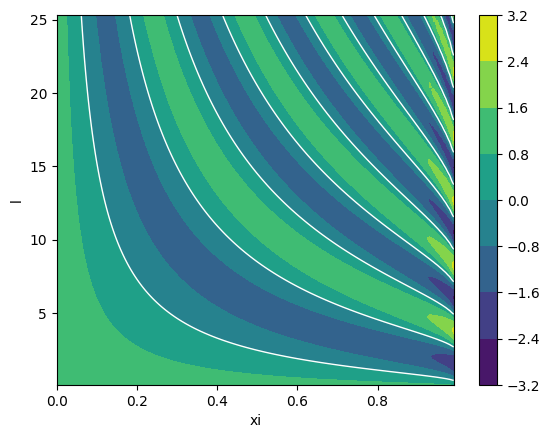

In [7]:
plt.figure()
plt.contourf(xax,lax, data)
plt.colorbar()
plt.contour(xax, lax, data, levels=[0], colors='w', linewidths=1)
plt.xlabel('xi')
plt.ylabel('l')
plt.show()

### each mirror ratio corresponds to a verticale slice of pitch angle xi
### the white lines are the non-integer legendre numbers l. The eigenvalues are l(l+1).

In [8]:
def find_eigenvalues_from_data(x_star, xax, lax, data, tol=1e-10):
    """Use precomputed data to bracket, then refine with brentq."""
    ix = np.argmin(np.abs(xax - x_star))   # nearest column
    col = data[:, ix]
    
    eigenvalues = []
    for i in range(len(lax) - 1):
        if np.isfinite(col[i]) and np.isfinite(col[i+1]):
            if col[i] * col[i+1] < 0:
                l_eig = brentq(
                    lambda l: make_M(l)[2](x_star),  # refine at exact x*
                    lax[i], lax[i+1],
                    xtol=tol
                )
                eigenvalues.append(l_eig)
    return np.array(eigenvalues)

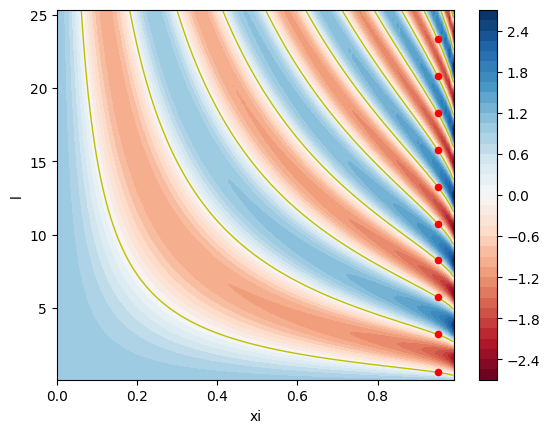

In [10]:
plt.figure()
x_star = 0.95
eigs = find_eigenvalues_from_data(x_star, xax, lax, data)

plt.contourf(xax, lax, data, levels=50, cmap='RdBu')
plt.colorbar()
plt.contour(xax, lax, data, levels=[0], colors='y', linewidths=1)
plt.scatter([x_star]*len(eigs), eigs, color='r', zorder=5, s=20)
plt.xlabel('xi')
plt.ylabel('l')

plt.show()

# the observation is that at higher mirror ratio (large xi) we need fewer l
# but at low mirror ratio, we need to go high in l to find solutions

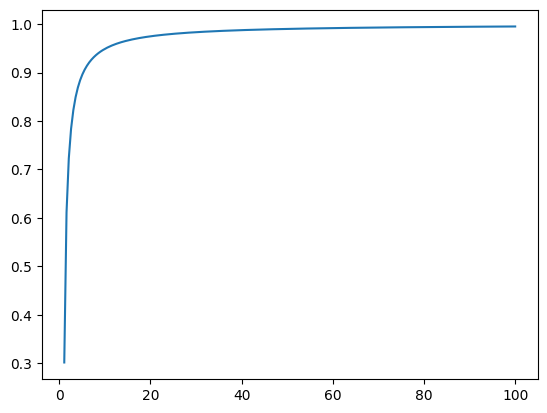

In [11]:
plt.figure()
Rm = np.linspace(1.1,100,200)
xi = [np.sqrt(1 - 1/R) for R in Rm]
plt.plot(Rm,xi)
#plt.xscale('log')

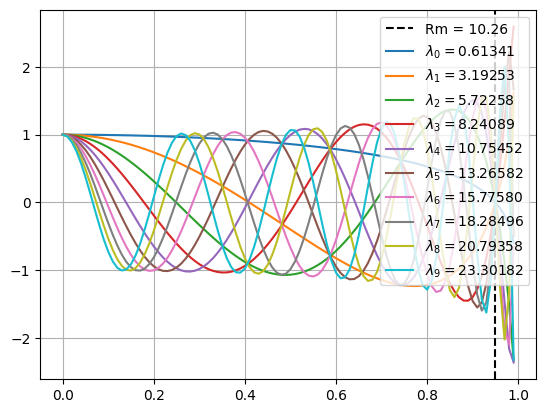

In [12]:
plt.figure()

Rm = 1/(1-x_star**2)
plt.axvline(x_star, ls='--', color='k', label=f"Rm = {Rm:.2f}")

M_arr = []
for j in range(10):
    _,_, M = make_M(eigs[j])
    Mx = [M(x) for x in xax]
    plt.plot(xax, Mx, label=rf"$\lambda_{{{j}}}={eigs[j]:.5f}$")

    M_arr.append(Mx)
plt.legend()
plt.grid()

plt.show()
M_arr = np.array(M_arr)

### this shows the first 10 eigenfunctions

## Physics

In [13]:
def ufunc(v, v0=60, vc=30, beta=1):
    # v_0 is beam energy, keV
    # v_c is critical velcoity, a function of Te
    # beta_m is a function of mass

    return ((v0**3 + vc**3)/(v**3 + vc**3) * (v/v0)**3 )**(beta/3)

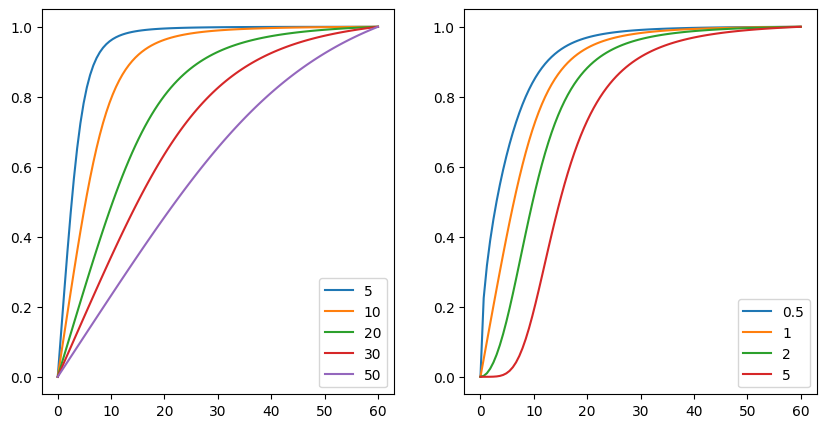

In [14]:
vax = np.linspace(0,60,100)

fig,axs = plt.subplots(1,2, figsize=(10,5))
for vc in [5,10,20,30,50]:
    axs[0].plot(vax,ufunc(vax, vc=vc), label=vc)

for beta in [0.5, 1, 2, 5]:
    axs[1].plot(vax,ufunc(vax, vc=12, beta=beta), label=beta)

axs[0].legend()
axs[1].legend()    

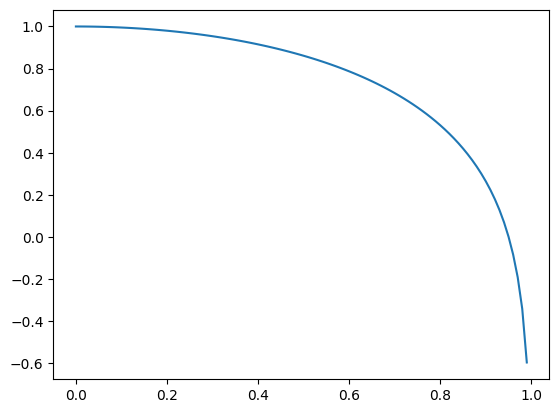

In [15]:
plt.figure()
plt.plot(xax,M_arr[0])

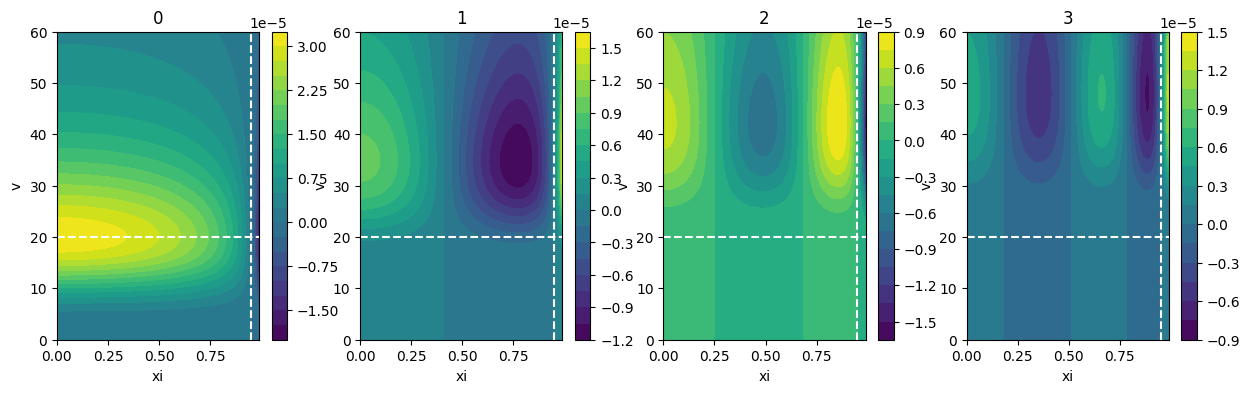

In [16]:
fig,axs = plt.subplots(1,4,figsize=(15,4))

for j in range(4):
    lamb=eigs[j]
    vc = 20
    beta = 5
    
    data = np.array([[m / (v**3 + vc**3) * ufunc(v,vc=vc,beta=beta)**lamb for m in M_arr[j]] for v in vax])

    C = axs[j].contourf(xax,vax,data,20)
    fig.colorbar(C, ax=axs[j])
    
    axs[j].axhline(vc, ls='--', color='w')
    axs[j].axvline(x_star, ls='--', color='w')
    
    axs[j].set_xlabel('xi')
    axs[j].set_ylabel('v')

    axs[j].set_title(j)

plt.show()

### this is the 2D eigenbasis for source functions. 
# It takes injection velocity and critical velocity as fixed inputs.

In [17]:
# Model Source term S(xi)
def S0(xi, R_b=2, sigma=0.05):

    # L = 1/rm = 1- xi^2
    xi_b = np.sqrt(1 - 1/R_b)

    return np.e**(- (xi-xi_b)**2 / sigma**2)

            

In [18]:
S = S0(xax)
alpha = np.sum(M_arr**2,axis=1)

dxi = np.diff(xax).mean()
Sj = np.sum([S*M for M in M_arr], axis=1) * dxi / alpha

Text(0.5, 1.0, '$S_j$')

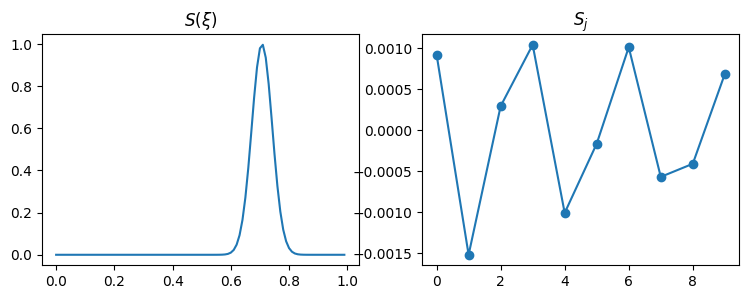

In [19]:
fig,axs = plt.subplots(1,2, figsize=(9,3))
axs[0].plot(xax,S0(xax))
axs[1].plot(Sj,'o-')

axs[0].set_title(r"$S(\xi)$")
axs[1].set_title(r"$S_j$")

## this shows a Gaussian source function and its decomposition

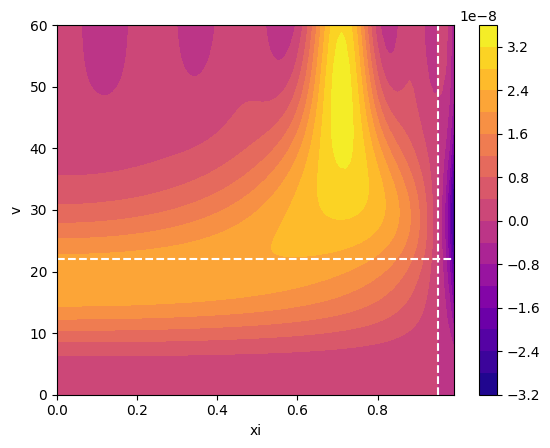

In [20]:
plt.figure()

vc = 22
beta = 4

data = np.zeros_like(data)
for j in range(10):
    lamb=eigs[j]
    data += np.array([[ Sj[j] * m / (v**3 + vc**3) * ufunc(v,vc=vc,beta=beta)**lamb for m in M_arr[j]] for v in vax])

plt.contourf(xax,vax,data,20, cmap='plasma')
plt.colorbar()

plt.axhline(vc, ls='--', color='w')
plt.axvline(x_star, ls='--', color='w')

plt.xlabel('xi')
plt.ylabel('v')

plt.show()


### This is the solution f_1! Fig 3, and Eq 14

In [21]:
# map to (v_perp, v_par) coordinates

# xi = v_par / v = cos theta

theta = np.arccos(xax)
nax = np.newaxis
vpar = vax[nax,:] * np.cos(theta)[:,nax]
vperp = vax[nax,:] * np.sin(theta)[:, nax]


# vpar = vax[nax,:] * xax[:,nax]
# vperp = vax[nax,:] * np.sqrt(1 - xax**2)[:, nax]

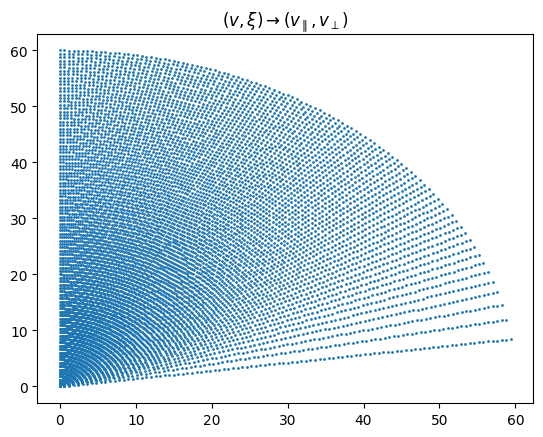

In [22]:
plt.figure()
plt.scatter(vpar, vperp, s=1)
plt.title(r"$(v,\xi) \to (v_\parallel, v_\perp)$")
plt.show()

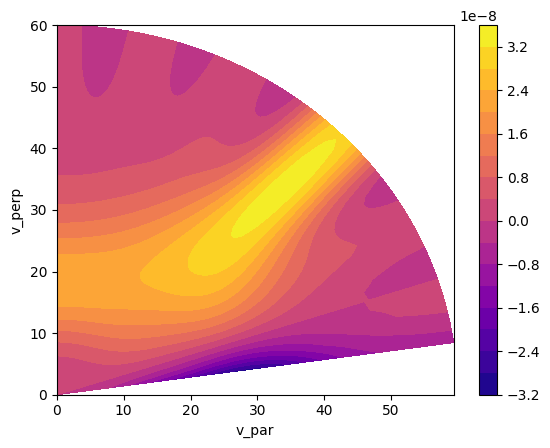

In [23]:
plt.figure()
plt.contourf(vpar,vperp,data.T,20, cmap='plasma')
plt.colorbar()
plt.xlabel("v_par")
plt.ylabel("v_perp")
plt.show()

### This is the solution mapped from (xi,v) to (par,perp) coordinates.

## Section 4 - Physics with B(z)

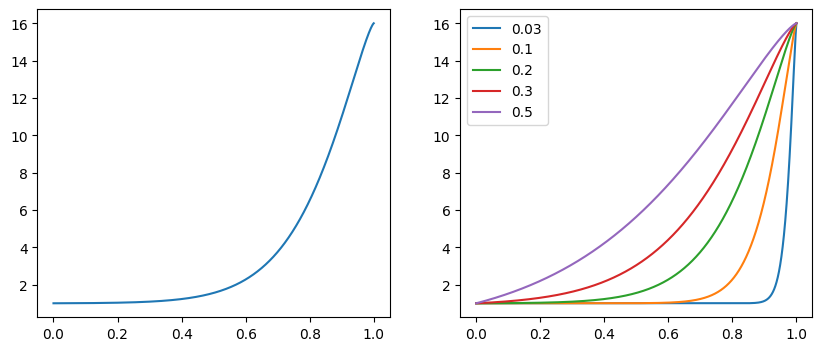

In [24]:
# Model for B(z), eq 56

def Bfunc(z,w=0.2, k=1.3, Rm=16):
    e1 = np.e**( -np.abs(np.abs(z) - 1)**k / w**k )
    e0 = np.e**( -1/w**k )
    B = 1 + (Rm - 1) * (e1 - e0)/(1 - e0)
    return B

fig,axs = plt.subplots(1,2,figsize=(10,4))

zax = np.linspace(0,1,10001)
for w in [0.03,0.1,0.2,0.3,0.5]:
    B = Bfunc(zax, w=w)
    axs[1].plot(zax,B, label=w)
axs[1].legend()

B = Bfunc(zax, w=0.2)
axs[0].plot(zax, B)

plt.show()

In [25]:
# this block uses root-find instead of spline

def get_zTP(Lambda, Bfunc, z_max=1):
    Rm = 1 / Lambda
    B0 = Bfunc(0)

    def zTP_single(L):
        try:
            return brentq(lambda z: Bfunc(z)/B0 - 1/L, 0, z_max)
        except:
            return z_max

    return np.array([zTP_single(L) for L in Lambda])

def get_tau(Lambda, Bfunc, z_TP):

    tau = []
    for L,Z in zip(Lambda, z_TP):
        z = np.linspace(0,Z,100,endpoint=False)
        B = Bfunc(z)
        dz = np.diff(z).mean()
        #integrand = np.sum(dz/np.sqrt(1 - L*B))/Z
        integrand = np.sum(dz/np.sqrt(1 - L*B))
        tau.append(integrand)

    return np.array(tau)

def get_1overB(Lambda, Bfunc, z_TP, tau):
    arr = []
    for Z,L,t in zip(z_TP, Lambda, tau):

        z = np.linspace(0,Z,100, endpoint=False)
        dz = np.diff(z).mean()
        
        Bz = Bfunc(z)
        integrand = 1/Bz / np.sqrt(1 - L*Bz)
        a = dz*np.sum(integrand)/t
        arr.append(a)

        #print(f"{Bfunc(z[-1]) * L}")

    return np.array(arr)

/tmp/ipykernel_1392187/1189443514.py:4: RuntimeWarning: divide by zero encountered in divide
  Rm = 1 / Lambda
/tmp/ipykernel_1392187/1189443514.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  return brentq(lambda z: Bfunc(z)/B0 - 1/L, 0, z_max)


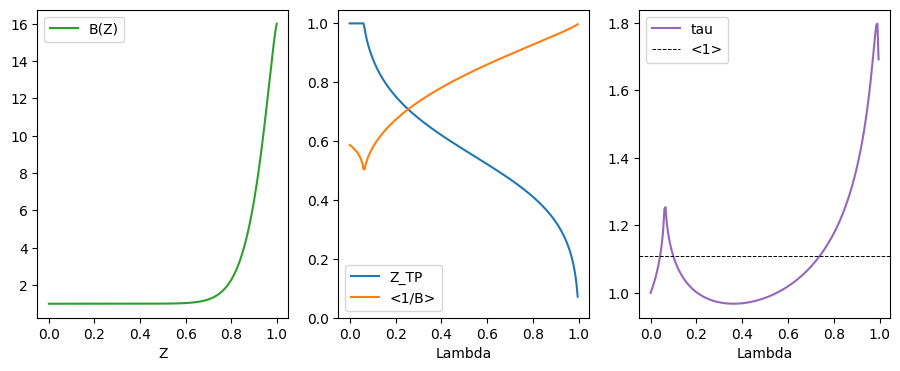

In [26]:
zax = np.linspace(0,1,1001)
lax = np.linspace(0,1,200,endpoint=False) # need to guard against passing particles, Lambda = 1/Rm has a min value

Rm = 16
w = 0.1
B = Bfunc(zax, w=w, Rm=Rm)

# ztp = get_zTP(lax, B, zax)
# tau = get_tau(lax, B, zax)
# avgB = get_1overB(lax,B, zax)

z_TP = get_zTP(lax, Bfunc)
tau = get_tau(lax, Bfunc, z_TP)
avgB = get_1overB(lax, Bfunc, z_TP, tau)

fig,axs = plt.subplots(1,3,figsize=(11,4))
axs[0].plot(zax,B, 'C2', label="B(Z)")
#axs[0].set_title('B(z)')
axs[0].set_xlabel("Z")


axs[1].plot(lax, z_TP, label="Z_TP")
#axs[1].set_title("z_TP")
axs[1].set_xlabel("Lambda")

axs[2].plot(lax, tau, 'C4', label="tau")
#axs[2].set_title('tau')
axs[2].set_xlabel("Lambda")

dL = np.diff(lax).mean()
IL = np.sum(tau) * dL
axs[2].axhline(IL, label="<1>", lw=0.7, ls='--', color='k')

axs[1].set_ylim(bottom=0)

axs[1].plot(lax, avgB, label="<1/B>")

for a in axs:
    a.legend()
plt.show()

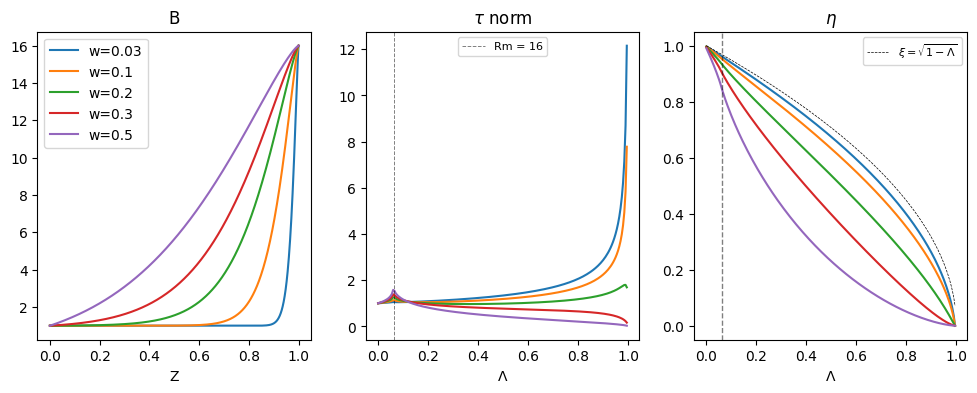

dict_keys([np.float64(0.9613403718717042), np.float64(0.9528689598167726), np.float64(0.9342301819286625), np.float64(0.9045493172756125), np.float64(0.8469529005891745)])

In [27]:
fig,axs = plt.subplots(1,3, figsize=(12,4))

Rm = 16

### get bounce integrals

zax = np.linspace(0,1,1001)
#lax = np.linspace(1/(Rm-1),1,200,endpoint=False) # need to guard against passing particles, Lambda = 1/Rm has a min value
lax = np.linspace(1e-3,1,200,endpoint=False)
eta_ax = lax.copy()

dL = np.diff(lax).mean()
dz = np.diff(zax).mean()
L = zax[-1] # this special case zmax is index-last, and it is already 1

n_ratio = 1

eta_data = {}
for w in [0.03,0.1,0.2,0.3,0.5]:

    # compute B
    B = Bfunc(zax, w=w)
    axs[0].plot(zax,B, label=f"w={w}")

    Bf = lambda z : Bfunc(z,w=w, Rm=Rm)
    z_TP = get_zTP(lax, Bf)

    # compute tau
    tau = get_tau(lax, Bf, z_TP)
    axs[1].plot(lax, tau)
    Itau = tau.sum() * dL 

    # compute avg B
    avgB = get_1overB(lax, Bf, z_TP, tau)
    spl_B = make_interp_spline(lax, avgB, k=3)

    # compute eta — cumulative sum along l, shape (N_l,)
    eta = 1 - tau.cumsum() * dL / Itau
    axs[2].plot(lax, eta)
    eta_TP = np.interp(1/Rm, lax, eta)
    eta_data[eta_TP] = (eta,spl_B)
    
axs[0].legend()
axs[0].set_title("B")
axs[1].set_title(r"$\tau$ norm")
axs[2].set_title(r"$\eta$")

axs[0].set_xlabel("Z")
axs[1].set_xlabel(r"$\Lambda$")
axs[2].set_xlabel(r"$\Lambda$")

axs[2].plot(lax, np.sqrt(1 - lax), 'k--', lw=0.5, label=r"$\xi = \sqrt{1 - \Lambda}$")
axs[2].legend(fontsize=8)

axs[1].axvline(1/Rm, color='k', ls='--', lw=0.7, alpha=0.5, label=f"Rm = {Rm}")
axs[2].axvline(1/Rm, color='k', ls='--', lw=1, alpha=0.5, label=f"Rm = {Rm}")
axs[1].legend(fontsize=8)

plt.show()

eta_data.keys()


# there is a mystery here. Eta_TP is higher than the values in the paper for large w
# also, the values here truncate at Lambda_TP, while eta(lamba=0)=1 in the paper.

In [28]:
def get_M_basis(eta_TP,
               lmin=0.1, lmax=30.1, nl=300, # eigenvalues
                N_eta=500 # eta resolution
    ):
    
    # eigenvalue axis
    l_scan = np.linspace(lmin, lmax, nl)
    
    # get M functions
    _,_,M_arr = np.transpose([make_M(l) for l in l_scan])
    
    # I probably want M(eta_TP)
    M_TP = np.array([M(eta_TP) for M in M_arr])
    
    M = interp1d(l_scan, M_TP) # this should be an oscillatory function
    
    # the zeros are eigenvalues
    indices = np.where(np.diff(np.sign(M_TP)))[0]
    eig_l = np.array([brentq(M, l_scan[i], l_scan[i+1]) for i in indices])
    
    # now get the precise M-basis
    _,_,M_arr = np.transpose([make_M(l) for l in eig_l])
    
    eta_ax = np.linspace(0, eta_TP, N_eta)
    M_basis =  np.array([[M(eta) for eta in eta_ax] for M in M_arr])

    return M_basis, eta_ax


def get_LM(M_basis, spl_B, l_ax):

    # needs l_ax as input. assumed to be l_ax(eta_ax) of which M=M(eta_ax)
    # assumes avg_1/B has already been computed for l_ax. This is spl_B.

    arr = []
    for M in M_basis:
        
        spl = make_interp_spline(l_ax[::-1], M[::-1], k=5)  # k=5 for smooth d2M
        
        dM   = spl.derivative(nu=1)
        d2M  = spl.derivative(nu=2)
        
        L1 = (4 * spl_B(l_ax) - 6 * l_ax ) * dM(l_ax)
        L2 = 4 * l_ax * ( spl_B(l_ax) - l_ax ) * d2M(l_ax)
        
        LM = L1 + L2
        arr.append(LM)

    return np.array(arr)

def get_H(M_basis, LM):

    # get alpha normalization
    alpha = np.sum(M_basis**2, axis=1)

    # compute MLM
    nax= np.newaxis
    cM = M_basis / alpha[:,nax]
    MLM = cM[:,nax] * LM[nax,:]

    deta = np.diff(eta_ax).mean() # already equal spaced!
    H = np.sum(MLM, axis=2) * deta 

    return H


In [29]:
class Mirror:

    def __init__(self, Rm=16, Nz=1001, N_Lambda=200, w=0.1):

        zax = np.linspace(0,1,1001)
        lax = np.linspace(1e-3,1,200,endpoint=False) 
        dL = np.diff(lax).mean()

        # compute B
        B = Bfunc(zax, w=w)
        Bf = lambda z : Bfunc(z,w=w, Rm=Rm)
        z_TP = get_zTP(lax, Bf)
    
        # compute tau
        tau = get_tau(lax, Bf, z_TP)
        Itau = tau.sum() * dL 
    
        # compute avg B
        avgB = get_1overB(lax, Bf, z_TP, tau)
        spl_B = make_interp_spline(lax, avgB, k=3)
    
        # compute eta — cumulative sum along l, shape (N_l,)
        eta = 1 - tau.cumsum() * dL / Itau
        eta_TP = np.interp(1/Rm, lax, eta)

        # Get M_basis
        M_basis, eta_ax = get_M_basis(eta_TP)

        # Compute H
        l_of_eta = make_interp_spline(eta[::-1], lax[::-1], k=3)
        l_ax = l_of_eta(eta_ax)
        LM = get_LM(M_basis, spl_B, l_ax)
        H = get_H(M_basis, LM)

        # Get Eigenvectors
        eigval, eigvec = np.linalg.eig(H)
        k = np.argmax(eigval)
        Ij = (eigvec[:,k][:,np.newaxis] * M_basis).sum(axis=0)


        # save
        self.Rm = Rm
        self.w = w
        self.zax = zax
        self.lax = lax
        
        self.B = B
        self.eta = eta
        self.tau = tau
        self.Itau = Itau
        self.eta_TP = eta_TP

        self.eta_ax = eta_ax
        self.l_ax = l_ax
        self.H = H
        self.eigval = eigval
        self.I1 = Ij / Ij[0]


        # compute density
        self.calc_dens()


    def calc_dens(self):

        # assumes H and I1 have been computed
        
        f_tau = make_interp_spline(self.lax, self.tau, k=3)
        f_I1 = make_interp_spline(self.l_ax[::-1], self.I1[::-1], k=3)
    
        L = np.linspace(1/self.Rm, 1, 100)
        dL = np.diff(L).mean()
    
        Inorm = np.sum(f_tau(L) * f_I1(L)) * dL
        norm = self.Itau/Inorm
    
        ne = []
        for B in self.B:
    
            L = np.linspace(1/self.Rm , 1/B - 1e-3 , 100)
            dL = np.diff(L).mean()         
        
            I = B * f_I1(L) / np.sqrt(1 - B*L)
            n = I.sum() * dL  * norm
        
            ne.append(n)

        self.ne = np.array(ne)
        

    def plot(self,axs):

        s = self
        axs[0,0].plot(s.zax, s.B, label=f"w={s.w}")
        axs[0,1].plot(s.lax, s.eta)

        axs[1,0].plot(s.eta_ax, s.I1)
        axs[1,1].plot(s.zax, s.ne)

In [30]:
arr = []
for w in [0.03,0.1,0.2,0.3,0.5]:
    M = Mirror(w=w)
    arr.append(M)

/tmp/ipykernel_1392187/1697639108.py:83: RuntimeWarning: divide by zero encountered in divide
  I = B * f_I1(L) / np.sqrt(1 - B*L)


0.9613403718717042
0.9528689598167726
0.9342301819286625
0.9045493172756125
0.8469529005891745


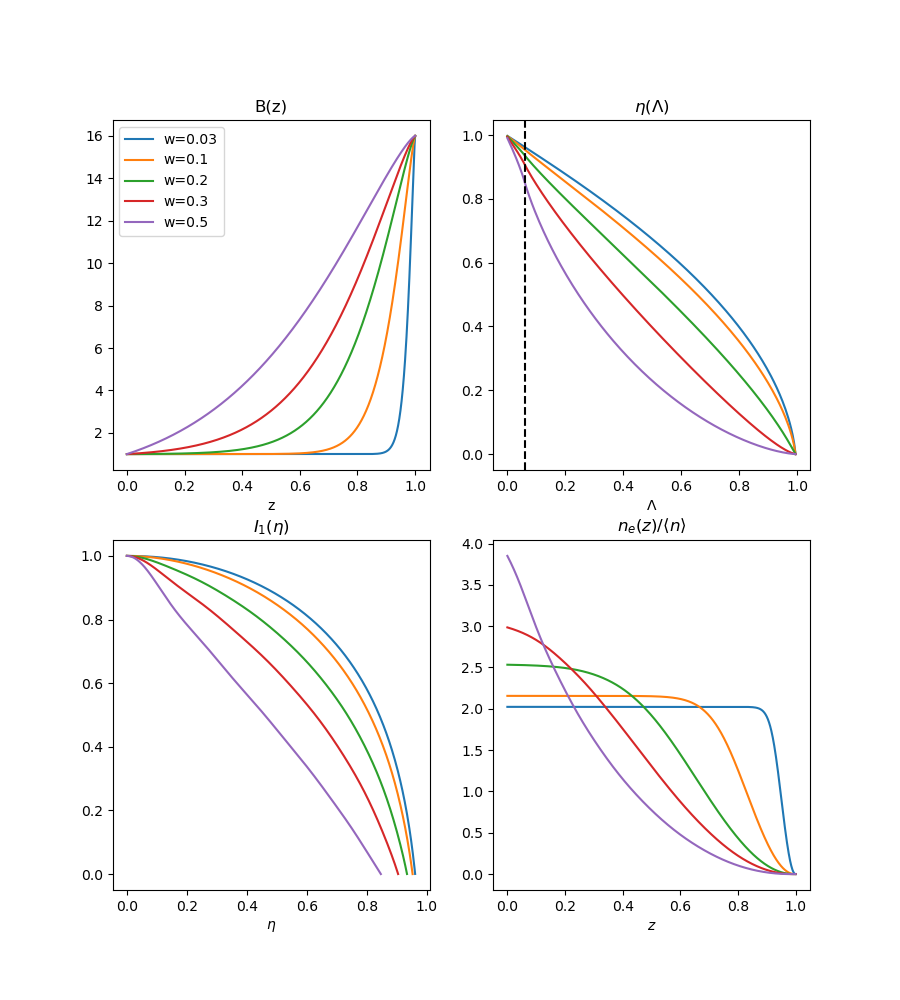

In [56]:
fig,axs = plt.subplots(2,2, figsize=(9,10))

for M in arr:

    M.plot(axs)
    print(M.eta_TP)

axs[0,1].axvline(1/M.Rm, ls='--', color='k')

axs[0,0].set_title("B(z)")
axs[0,0].set_xlabel("z")

axs[0,1].set_title(r"$\eta(\Lambda)$")
axs[0,1].set_xlabel(r"$\Lambda$")

axs[1,0].set_title(r"$I_1(\eta)$")
axs[1,0].set_xlabel(r"$\eta$")

axs[1,1].set_title(r"$n_e(z) / \left< n \right>$")
axs[1,1].set_xlabel(r"$z$")

axs[0,0].legend()
plt.show()

In [ ]:
### STOP
# below this is debug code

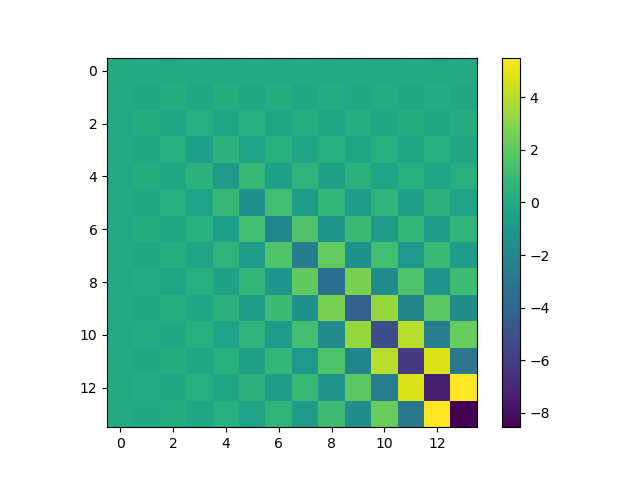

np.float64(0.011650610141164641)

In [203]:
#H = get_H(M_basis, LM)
H = M.H

plt.figure()
plt.imshow(H)
plt.colorbar()
plt.show()


# Is H symmetric? not precisely
np.max(np.abs(H - H.T))

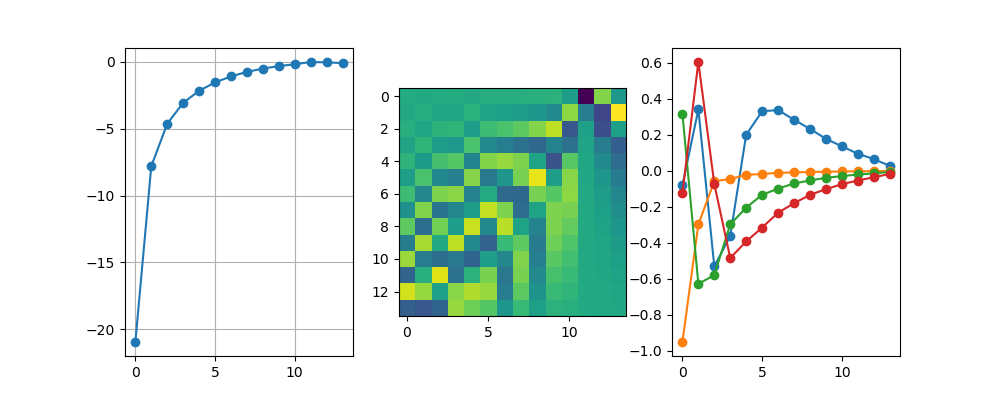

In [204]:
eigval, eigvec = np.linalg.eig(H)

fig,axs = plt.subplots(1,3, figsize=(10,4))
axs[0].plot(eigval, 'o-')

for v in eigvec.T[10:]:
    axs[2].plot(v, 'o-')

axs[1].imshow(eigvec)

axs[0].grid()
plt.show()

In [205]:
fig,axs = plt.subplots(2,1)

for j in [9,10,11,12]:
    Ij = (eigvec[j][:,np.newaxis] * M_basis).sum(axis=0)
    axs[0].plot(eta_ax, -Ij)
    
    Ij = (eigvec[:,j][:,np.newaxis] * M_basis).sum(axis=0)
    axs[1].plot(eta_ax, -Ij)

axs[0].axvline(eta_TP, color='k', ls='--')
plt.show()

### by 2-choice elimination, it seems eigvec[:,j] is correct. WHY is this true?

# the eigenvalues are negative, so I invert the eigenvector

ValueError: x and y must have same first dimension, but have shapes (200,) and (500,)

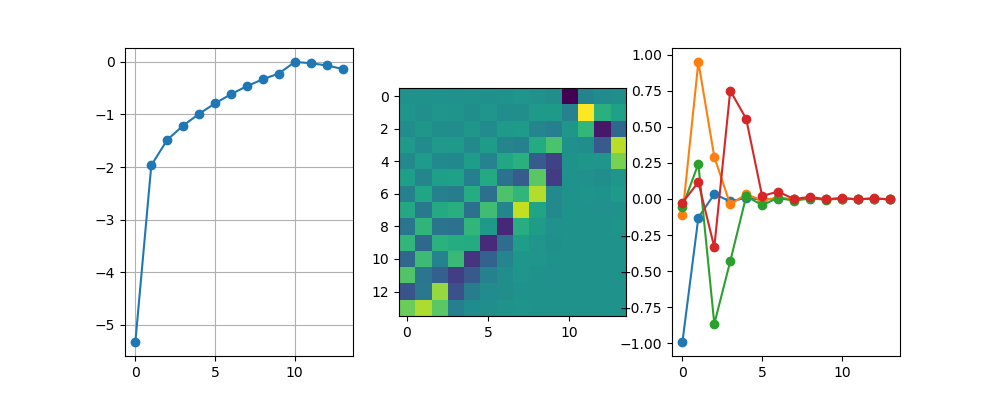

In [63]:
# new eta_TP
eigval, eigvec = np.linalg.eig(H)

fig,axs = plt.subplots(1,3, figsize=(10,4))
axs[0].plot(eigval, 'o-')

for v in eigvec.T[10:]:
    axs[2].plot(v, 'o-')

axs[1].imshow(eigvec)

axs[0].grid()
plt.show()

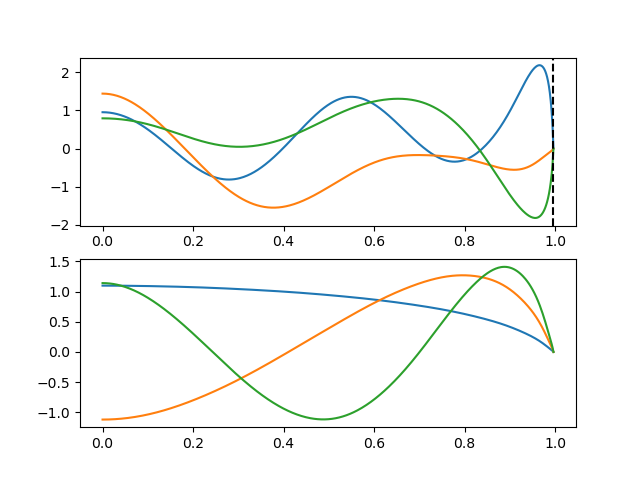

In [64]:
fig,axs = plt.subplots(2,1)

for j in [10,11,12]:
    Ij = (eigvec[j][:,np.newaxis] * M_basis).sum(axis=0)
    axs[0].plot(eta_ax, -Ij)
    
    Ij = (eigvec[:,j][:,np.newaxis] * M_basis).sum(axis=0)
    axs[1].plot(eta_ax, -Ij)

axs[0].axvline(eta_TP, color='k', ls='--')
plt.show()

### by 2-choice elimination, it seems eigvec[:,j] is correct. WHY is this true?

# the eigenvalues are negative, so I invert the eigenvector

In [88]:
k = 20


array([ 1.        ,  1.00448062,  1.00897425, ..., 15.98748888,
       15.99491775, 16.        ], shape=(1001,))

-0.7530265873971432
-0.9108052637541721
-1.3329064844612188
-1.6643857911116449
-1.8511448133775472


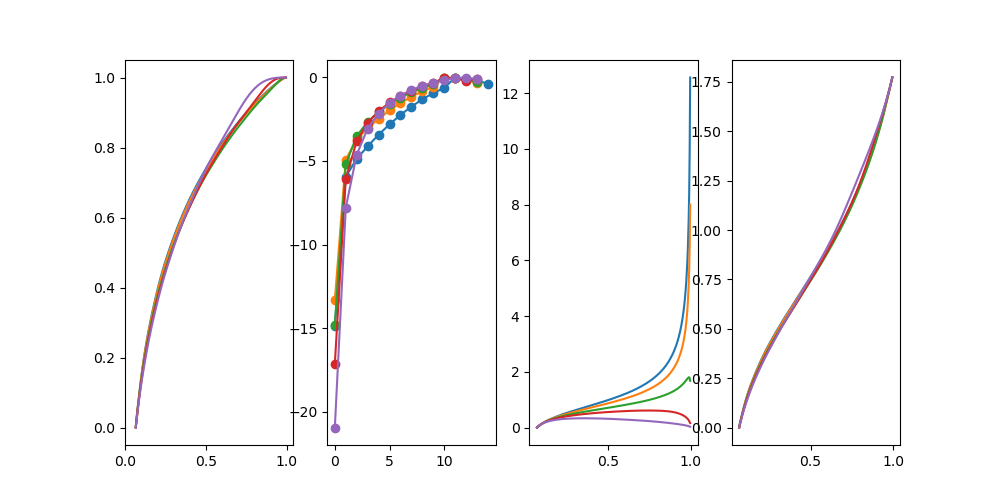

In [199]:
fig,axs = plt.subplots(1,4,figsize=(10,5))

for M in arr:
    axs[0].plot(M.l_ax, M.I1)
    axs[1].plot(M.eigval, 'o-')
    #axs[1].plot(M.lax, M.tau)

    Mtau = make_interp_spline(M.lax, M.tau, k=3)
    axs[2].plot(M.l_ax, Mtau(M.l_ax) * M.I1)

    dL = np.diff(M.l_ax).mean()
    Inorm = np.sum(Mtau(M.l_ax) * M.I1) * dL

    MB = 0.8

    axs[3].plot( M.l_ax, MB * M.I1 / np.sqrt(1 - MB* M.l_ax) )
    print(M.Itau/Inorm)
axs[0].set_xlim(left=0)
plt.show()


/var/folders/ml/t76cj23s09n475x_32xpgb3m0000gn/T/ipykernel_79276/2420188547.py:21: RuntimeWarning: divide by zero encountered in divide
  I = B * MI1(L) / np.sqrt(1 - B*L)


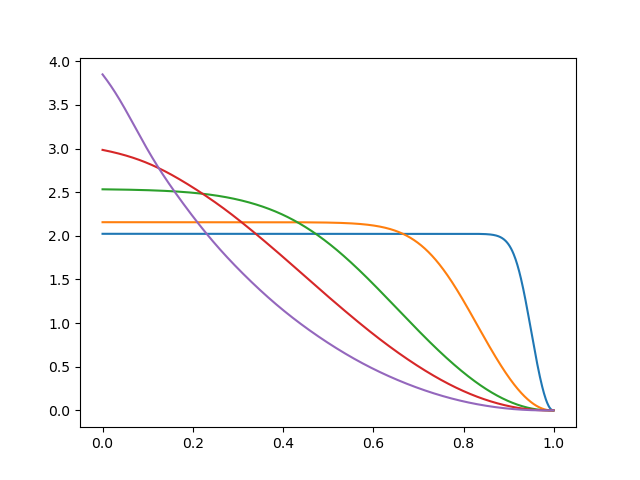

In [44]:
plt.figure()

for M in arr:

    Mtau = make_interp_spline(M.lax, M.tau, k=3)
    MI1 = make_interp_spline(M.l_ax[::-1], M.I1[::-1], k=3)

    L = np.linspace(1/M.Rm, 1, 100)
    dL = np.diff(L).mean()

    Inorm = np.sum(Mtau(L) * MI1(L)) * dL
    norm = M.Itau/Inorm


    narr = []
    for B in M.B:

        L = np.linspace(1/M.Rm , 1/B - 1e-3 , 100)
        dL = np.diff(L).mean()         
    
        I = B * MI1(L) / np.sqrt(1 - B*L)
        ne = I.sum() * dL  * norm
    
        narr.append(ne)
    
    plt.plot(M.zax, narr)


plt.show()

In [42]:
M.B

array([ 1.        ,  1.00448062,  1.00897425, ..., 15.98748888,
       15.99491775, 16.        ], shape=(1001,))

array([0.0625    , 0.0625002 , 0.0625004 , 0.0625006 , 0.0625008 ,
       0.062501  , 0.0625012 , 0.0625014 , 0.0625016 , 0.06250181,
       0.06250201, 0.06250221, 0.06250241, 0.06250261, 0.06250281,
       0.06250301, 0.06250321, 0.06250341, 0.06250361, 0.06250381,
       0.06250401, 0.06250421, 0.06250441, 0.06250461, 0.06250481,
       0.06250501, 0.06250522, 0.06250542, 0.06250562, 0.06250582,
       0.06250602, 0.06250622, 0.06250642, 0.06250662, 0.06250682,
       0.06250702, 0.06250722, 0.06250742, 0.06250762, 0.06250782,
       0.06250802, 0.06250822, 0.06250842, 0.06250863, 0.06250883,
       0.06250903, 0.06250923, 0.06250943, 0.06250963, 0.06250983,
       0.06251003, 0.06251023, 0.06251043, 0.06251063, 0.06251083,
       0.06251103, 0.06251123, 0.06251143, 0.06251163, 0.06251184,
       0.06251204, 0.06251224, 0.06251244, 0.06251264, 0.06251284,
       0.06251304, 0.06251324, 0.06251344, 0.06251364, 0.06251384,
       0.06251404, 0.06251424, 0.06251444, 0.06251464, 0.06251

In [30]:
dL

np.float64(2.005942188365976e-07)